<a href="https://colab.research.google.com/github/polaroso777/Abstractas/blob/main/Ejercicios/_Diabetes_Funcional_Equipo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/Inteligencia Computacional/pima-indians-diabetes.data', delimiter=',')

In [ ]:
#Sparar los datos de entrada y las etiquetas deseadas
X = dataset[:,0:8]
Y = dataset[:,8]

In [ ]:
# Normalizar los datos
scaler = MinMaxScaler(feature_range=(-1, 1))
rescaledX = scaler.fit_transform(X)

In [ ]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5)


In [ ]:
# Definir la entrada
inputs = Input(shape=(8,))

In [ ]:
# Capas ocultas con Dropout para reducir el sobreajuste
hidden1 = Dense(12, activation='relu')(inputs)
dropout1 = Dropout(0.3)(hidden1)
hidden2 = Dense(6, activation='relu')(dropout1)
dropout2 = Dropout(0.3)(hidden2)
output = Dense(1, activation='sigmoid')(dropout2)

In [ ]:
# Crear el modelo funcional
model = Model(inputs=inputs, outputs=output)

In [ ]:
# Compilar el modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Entrenar el modelo
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=150, batch_size=16)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5670 - loss: 11.0004 - val_accuracy: 0.5286 - val_loss: 5.0790
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5318 - loss: 8.3728 - val_accuracy: 0.5234 - val_loss: 2.7060
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6150 - loss: 5.7025 - val_accuracy: 0.5234 - val_loss: 1.7440
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6002 - loss: 4.4565 - val_accuracy: 0.5443 - val_loss: 1.1747
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6428 - loss: 3.1366 - val_accuracy: 0.5885 - val_loss: 0.8597
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6752 - loss: 2.5497 - val_accuracy: 0.6250 - val_loss: 0.7841
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6676 - loss: 1.6441 - val_accuracy: 0.6224 - val_loss: 0.7405
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6632 - loss: 1.6563 - val_accuracy: 0.6276 -

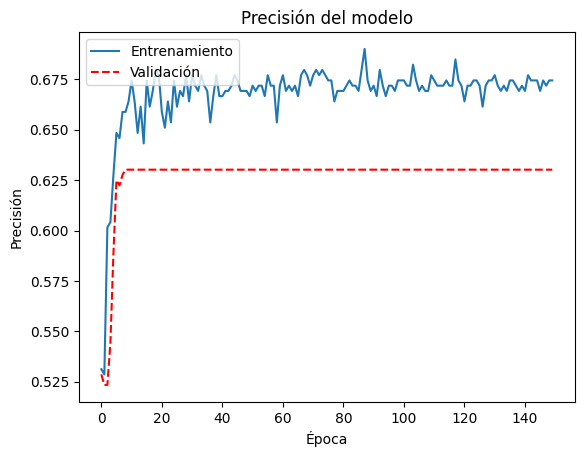

In [ ]:
# Graficar precisión
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'], 'r--')
plt.title('Precisión del modelo')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
plt.savefig('PrecisionDiabetesKeras.png')
plt.show()

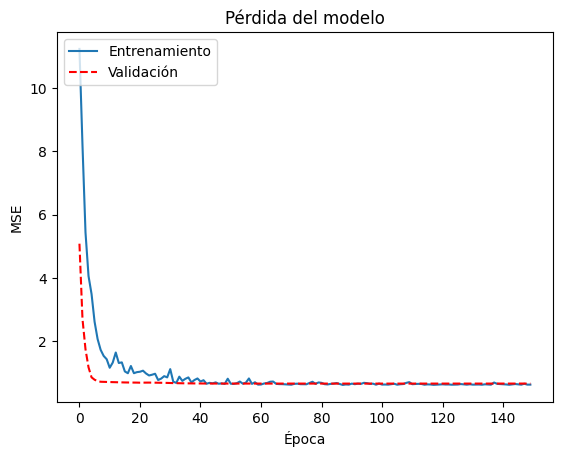

In [ ]:
# Graficar pérdida
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'], 'r--')
plt.title('Pérdida del modelo')
plt.ylabel('MSE')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
plt.savefig('PerdidaDiabetesKeras.png')
plt.show()

In [ ]:
# Resumen del modelo
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │             108 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 581 (2.27 KB)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 388 (1.52 KB)